# Audit of the experiment folders

In [ ]:
import sys, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import yaml

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
EXP = REPO / "experiments"
DATA = REPO / "data" / "link_prediction"
Path("figures").mkdir(exist_ok=True)

COL = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

rows = []
for f in sorted(EXP.iterdir()):
    if not (f / "config.yaml").exists():
        continue
    cfg = yaml.safe_load(open(f / "config.yaml"))
    dataset = Path(cfg["data_dir"]).name
    rows.append({"run": f.name, "dataset": dataset, "L": int(cfg["num_layers"]), "encoding": cfg["encoding_scheme"],
                 "aggregations": ",".join(cfg["aggregations"]), "theta_der": float(cfg["derivation_threshold"]),
                 "target": cfg.get("target_predicate"), "lr": cfg.get("learning_rate"),
                 "epochs": len(pd.read_csv(f / "train_loss.tsv", sep="\t")),
                 "folder": f, "data_dir": DATA / dataset})
runs = pd.DataFrame(rows).sort_values(["dataset", "L"]).reset_index(drop=True)

GROUPS = {"WN18RRv1": (["WN18RRv1"], "wn18rrv1"),
          "ADNI connectomes": (["data_v10", "seed_81"], "adni_connectomes")}
runs.drop(columns=["folder", "data_dir"])

,run,dataset,L,encoding,aggregations,theta_der,target,lr,epochs
0,WN18RRv1_L1,WN18RRv1,1,iclr22,max,0.0001,NaN,0.010,972
1,WN18RRv1_L2,WN18RRv1,2,iclr22,"max,max",0.0001,NaN,0.010,576
2,WN18RRv1_L3,WN18RRv1,3,iclr22,"max,max,max",0.0001,NaN,0.010,648
3,data_v10_L1,data_v10,1,canonical,max,0.0001,positive,0.001,315
4,data_v10_L2,data_v10,2,canonical,"max,max",0.0001,positive,0.001,15039
5,data_v10_L3,data_v10,3,canonical,"max,max,max",0.0001,positive,0.001,6844
6,seed_81_L1,seed_81,1,canonical,max,0.0001,positive,0.001,425
7,seed_81_L2,seed_81,2,canonical,"max,max",0.0001,positive,0.001,10026
8,seed_81_L3,seed_81,3,canonical,"max,max,max",0.0001,positive,0.001,3347


In [ ]:
import torch

def load_params(path):
    m = torch.load(path, weights_only=False, map_location="cpu")
    return m, {n: p.detach().cpu().numpy() for n, p in m.named_parameters()}

def target_position(r):
    unary = {p: int(i) for k, i, p in (l.split("\t") for l in open(r.folder / "internal_encoder.tsv").read().splitlines()) if k == "UNARY"}
    if r.encoding == "iclr22":
        rule = open(r.folder / "explanations.txt").read().splitlines()[1]
        return unary["unary-for-" + re.search(r"<([^>]+)>", rule).group(1)]
    return unary["positive"]

## Depth configs

In [3]:
models, rows = {}, []
for _, r in runs.iterrows():
    m, params = load_params(r.folder / "model.pt")
    models[r.run] = (m, params)
    rows.append({"run": r.run, "dimensions": m.dimensions, "target": r.target, "lr": r.lr, "epochs": r.epochs,
                 "n params": sum(p.size for p in params.values())})
pd.DataFrame(rows)

/Users/reubenmatthew/.pyenv/versions/rhul_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,run,dimensions,target,lr,epochs,n params
0,WN18RRv1_L1,"[9, 9]",NaN,0.010,972,414
1,WN18RRv1_L2,"[9, 18, 9]",NaN,0.010,576,1647
2,WN18RRv1_L3,"[9, 18, 18, 9]",NaN,0.010,648,3285
3,data_v10_L1,"[95, 95]",positive,0.001,315,117420
4,data_v10_L2,"[95, 190, 95]",positive,0.001,15039,469585
5,data_v10_L3,"[95, 190, 190, 95]",positive,0.001,6844,939075
6,seed_81_L1,"[117, 117]",positive,0.001,425,164385
7,seed_81_L2,"[117, 234, 117]",positive,0.001,10026,657423
8,seed_81_L3,"[117, 234, 234, 117]",positive,0.001,3347,1314729


## Matrices

,run,dataset,L,matrix,shape,min,max,zero pct
0,WN18RRv1_L1,WN18RRv1,1,A1,"(9, 9)",0.0,2.651109,96.296296
1,WN18RRv1_L1,WN18RRv1,1,B1,"(4, 9, 9)",0.0,6.068105,97.839506
2,WN18RRv1_L2,WN18RRv1,2,A1,"(18, 9)",0.0,2.082898,83.333333
3,WN18RRv1_L2,WN18RRv1,2,B1,"(4, 18, 9)",0.0,2.999752,87.654321
4,WN18RRv1_L2,WN18RRv1,2,A2,"(9, 18)",0.0,1.176494,88.271605
5,WN18RRv1_L2,WN18RRv1,2,B2,"(4, 9, 18)",0.0,2.289836,85.030864
6,WN18RRv1_L3,WN18RRv1,3,A1,"(18, 9)",0.0,2.527556,84.567901
7,WN18RRv1_L3,WN18RRv1,3,B1,"(4, 18, 9)",0.0,2.544060,90.586420
8,WN18RRv1_L3,WN18RRv1,3,A2,"(18, 18)",0.0,4.493258,63.888889
9,WN18RRv1_L3,WN18RRv1,3,B2,"(4, 18, 18)",0.0,7.153991,68.827160


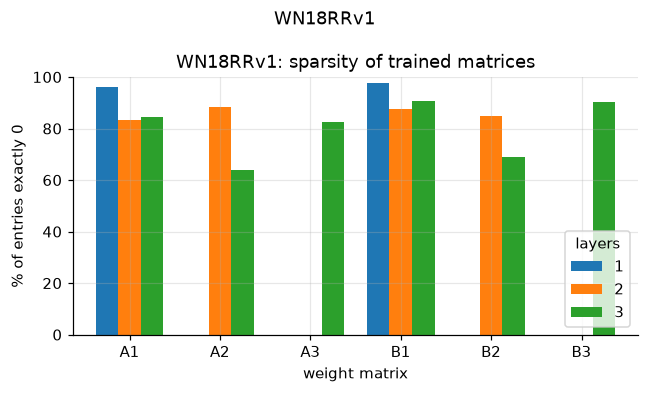

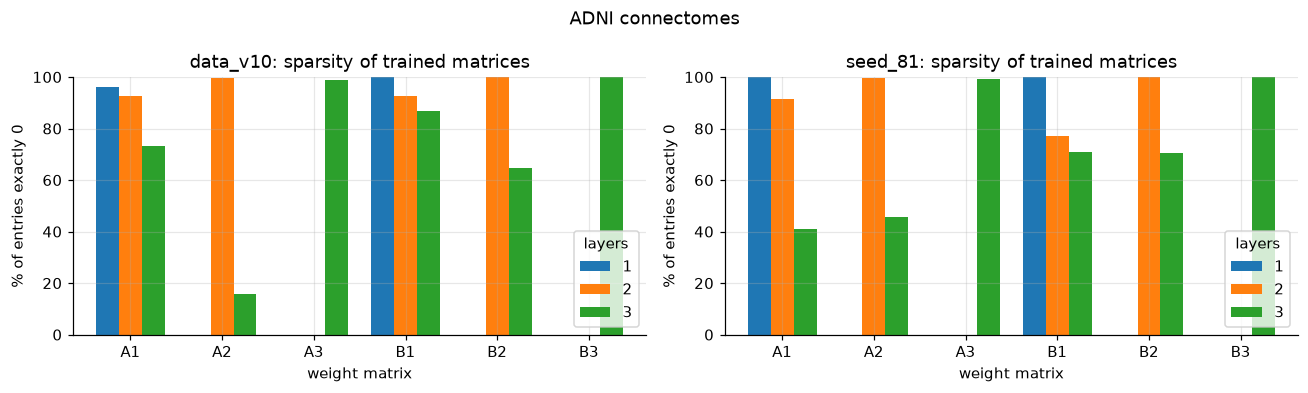

In [4]:
rows = []
for _, r in runs.iterrows():
    m, params = models[r.run]
    for l in range(1, m.num_layers + 1):
        for name, key in [("A", f"lin_selfs.{l-1}.weight"), ("B", f"convs.{l-1}.weights")]:
            w = params[key]
            rows.append({"run": r.run, "dataset": r.dataset, "L": r.L, "matrix": f"{name}{l}", "shape": w.shape,
                         "min": w.min(), "max": w.max(), "zero pct": (w == 0).mean() * 100})
weights = pd.DataFrame(rows)
display(weights)

for name, (dsets, stem) in GROUPS.items():
    fig, axes = plt.subplots(1, len(dsets), figsize=(6 * len(dsets), 3.6), squeeze=False)
    for ax, ds in zip(axes[0], dsets):
        piv = weights[weights.dataset == ds].pivot(index="matrix", columns="L", values="zero pct")
        piv.plot.bar(ax=ax, rot=0, width=0.75, color=[COL[L] for L in piv.columns])
        ax.set(ylim=(0, 100), xlabel="weight matrix", ylabel="% of entries exactly 0", title=f"{ds}: sparsity of trained matrices")
        ax.legend(title="layers", loc="lower right")
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/sparsity_{stem}.png"); plt.show()

## Weights over the checkpoints

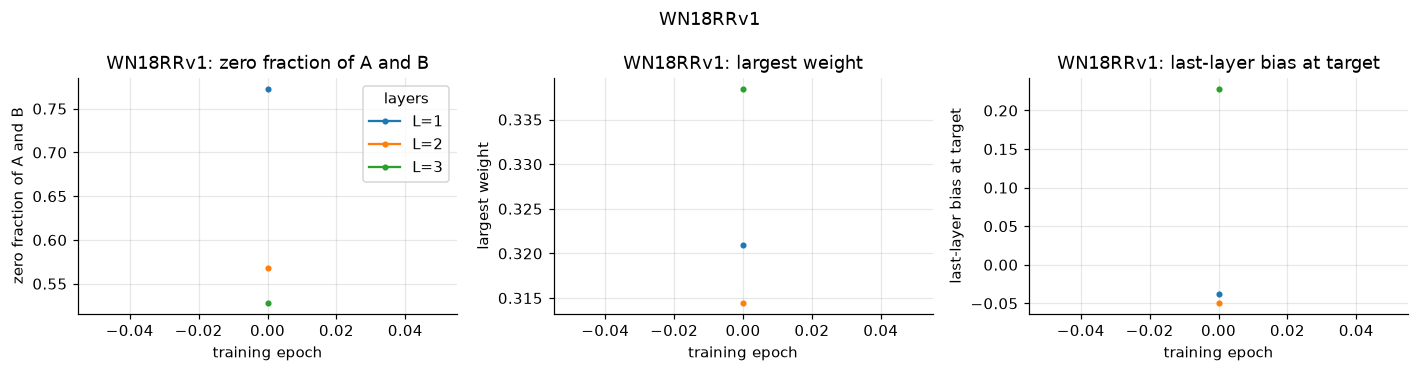

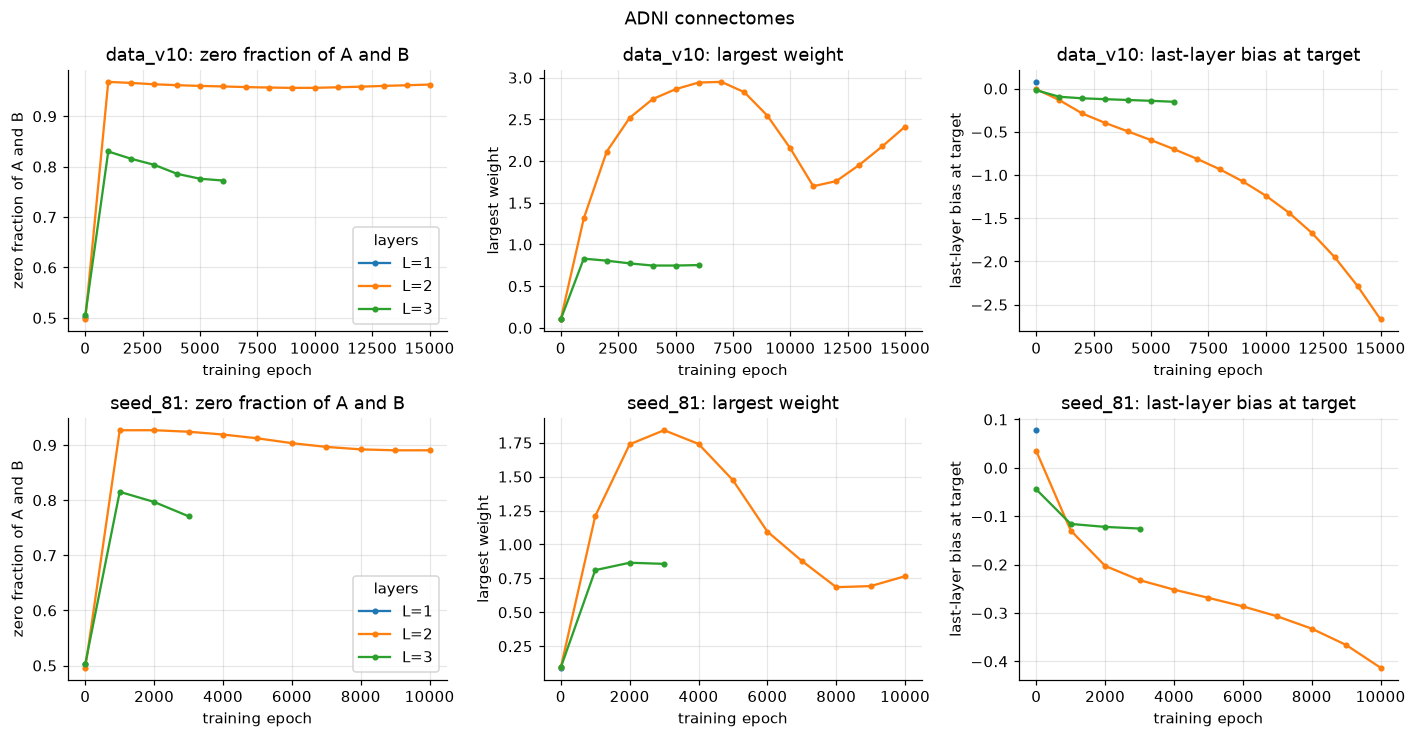

In [7]:
traj = []
for _, r in runs.iterrows():
    pos = target_position(r)
    for ck in sorted((r.folder / "checkpoints").glob("*.pt"), key=lambda p: int(re.search(r"Epoch(\d+)", p.name).group(1))):
        m, params = load_params(ck)
        AB = np.concatenate([v.ravel() for n, v in params.items() if "bias" not in n])
        traj.append({"dataset": r.dataset, "L": r.L, "epoch": int(re.search(r"Epoch(\d+)", ck.name).group(1)),
                     "zero fraction of A and B": (AB == 0).mean(), "largest weight": AB.max(),
                     "last-layer bias at target": params[f"lin_selfs.{m.num_layers-1}.bias"][pos]})
traj = pd.DataFrame(traj)

cols = ["zero fraction of A and B", "largest weight", "last-layer bias at target"]
for name, (dsets, stem) in GROUPS.items():
    fig, axes = plt.subplots(len(dsets), 3, figsize=(13, 3.4 * len(dsets)), squeeze=False)
    for i, ds in enumerate(dsets):
        for j, col in enumerate(cols):
            ax = axes[i, j]
            for L, g in traj[traj.dataset == ds].groupby("L"):
                ax.plot(g.epoch, g[col], "o-", ms=3, color=COL[L], label=f"L={L}")
            ax.set(title=f"{ds}: {col}", xlabel="training epoch", ylabel=col)
            if j == 0: ax.legend(title="layers")
    fig.suptitle(name); plt.tight_layout(); plt.savefig(f"figures/checkpoints_{stem}.png"); plt.show()